In [3]:
import os
import scanpy as sc
import numpy as np
from scipy.io import mmread
from scipy.sparse import csr_matrix

AF = "/data1/bfernando/DE_project/alvinfry"
OUT_DIR = f"{AF}/h5ad"
os.makedirs(OUT_DIR, exist_ok=True)
SAMPLES = ["Col-0", "pFACT", "pHORST"]

In [4]:
# look the data 
sample = SAMPLES[0]
mtx_file  = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat.mtx"
cols_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_cols.txt"
rows_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_rows.txt"
!head -5 {mtx_file} {cols_file} {rows_file}

# genes are --> 82968 , this is 3 times the gene count

==> /data1/bfernando/DE_project/alvinfry/counts_cr-like-em/Col-0/alevin/quants_mat.mtx <==
%%MatrixMarket matrix coordinate real general
% written by sprs
192259 82968 14996054
2 4 3
2 8 1

==> /data1/bfernando/DE_project/alvinfry/counts_cr-like-em/Col-0/alevin/quants_mat_cols.txt <==
AT1G01010.Araport11.447
AT1G01040.Araport11.447
AT1G01110.Araport11.447
AT1G01160.Araport11.447
AT1G01180.Araport11.447

==> /data1/bfernando/DE_project/alvinfry/counts_cr-like-em/Col-0/alevin/quants_mat_rows.txt <==
CGCAGGTCATTCGCTA
CAACTCCCATGCTGTC
CACTCCATCCAGAGGA
AACACCGCACATATAG
CACTAACGTGCACCAC


In [5]:
all_adata = {}          # keep them in memory for the next cells

for sample in SAMPLES:

    print("=" * 60)
    print(sample)

    mtx_file  = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat.mtx"
    cols_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_cols.txt"
    rows_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_rows.txt"

    # --- read the matrix ---------------------------------------------------
    matrix = mmread(mtx_file)
    matrix = matrix.tocsr()          # csr = fast row slicing

    # --- read the names ----------------------------------------------------
    column_names = []
    for line in open(cols_file):
        column_names.append(line.strip())

    barcode_names = []
    for line in open(rows_file):
        barcode_names.append(line.strip())

    print("  matrix shape :", matrix.shape)

    # --- find the S / U / A blocks ----------------------------------------
    n_genes = len(column_names) // 3

    start_S = 0
    end_S   = n_genes
    start_U = n_genes
    end_U   = n_genes * 2
    start_A = n_genes * 2
    end_A   = n_genes * 3

    block_S = matrix[:, start_S:end_S]
    block_U = matrix[:, start_U:end_U]
    block_A = matrix[:, start_A:end_A]

    # --- add the three layers together ------------------------------------
    counts = block_S + block_U + block_A
    counts = csr_matrix(counts)      # make sure it stays sparse

    gene_names = column_names[start_S:end_S]

    # --- build the AnnData object -----------------------------------------
    adata = sc.AnnData(counts)
    adata.obs_names = barcode_names
    adata.var_names = gene_names

    # record where it came from, so the file explains itself later
    adata.obs["sample"] = sample
    adata.uns["source"] = f"{AF}/counts_cr-like-em/{sample}"
    adata.uns["resolution"] = "cr-like-em"
    adata.uns["layers_summed"] = "S+U+A"
    adata.uns["filtered"] = False

    #uns = unstructured.

    print("  genes        :", n_genes)
    print("  barcodes     :", adata.n_obs)
    print("  total UMI    :", round(float(adata.X.sum())))

    # --- save --------------------------------------------------------------
    out_file = f"{OUT_DIR}/{sample}_cr-like-em_raw.h5ad"
    adata.write_h5ad(out_file, compression="gzip")
    print("  wrote        :", out_file)
    print("  size         :", round(os.path.getsize(out_file) / 1e6, 1), "MB")

    all_adata[sample] = adata

print("=" * 60)
print("done -", len(all_adata), "samples loaded")

Col-0


/data1/tmp/ipykernel_966550/897229559.py:13: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = mmread(mtx_file)


  matrix shape : (192259, 82968)
  genes        : 27656
  barcodes     : 192259
  total UMI    : 18123357
  wrote        : /data1/bfernando/DE_project/alvinfry/h5ad/Col-0_cr-like-em_raw.h5ad
  size         : 45.3 MB
pFACT


/data1/tmp/ipykernel_966550/897229559.py:13: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = mmread(mtx_file)


  matrix shape : (200283, 82968)
  genes        : 27656
  barcodes     : 200283
  total UMI    : 29835121
  wrote        : /data1/bfernando/DE_project/alvinfry/h5ad/pFACT_cr-like-em_raw.h5ad
  size         : 64.7 MB
pHORST


/data1/tmp/ipykernel_966550/897229559.py:13: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = mmread(mtx_file)


  matrix shape : (193477, 82968)
  genes        : 27656
  barcodes     : 193477
  total UMI    : 21889175
  wrote        : /data1/bfernando/DE_project/alvinfry/h5ad/pHORST_cr-like-em_raw.h5ad
  size         : 42.9 MB
done - 3 samples loaded


Adds per-barcode columns to `.obs`: using the calculate_qc_metric function

| column | meaning |
|---|---|
| `total_counts` | total UMIs in that barcode |
| `n_genes_by_counts` | how many distinct genes it detected |
| `pct_counts_organellar` | % of its UMIs from chloroplast/mito genes |

`ATCG*` = chloroplast genome, `ATMG*` = mitochondrial genome. Nuclei contain neither
organelle, so a clean nuclei prep should be low.

In [6]:
# more on the Scanpy calculate_qc_metric
# https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html
# returns 
# 1) total_counts - total UMIs in that barcode 
# 2) n_genes_by_counts - how many distinct genes it detected
# 3) pct_counts_organellar - % of its UMIs from chloroplast/mito genes

for sample in SAMPLES:
    adata = all_adata[sample]

    # flag the organellar genes
    adata.var["organellar"] = adata.var_names.str.startswith(("ATCG", "ATMG"))  # Adds a True/False column to .var marking the Mt and Cp genes

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["organellar"],
        inplace=True,
        percent_top=None,
        log1p=False,
    )

    print(f"{sample:8s} barcodes={adata.n_obs:>8,}  "
          f"median UMI={adata.obs['total_counts'].median():>7.0f}  "
          f"median genes={adata.obs['n_genes_by_counts'].median():>6.0f}  "
          f"median %organellar={adata.obs['pct_counts_organellar'].median():>5.1f}")

Col-0    barcodes= 192,259  median UMI=     64  median genes=    61  median %organellar=  3.7
pFACT    barcodes= 200,283  median UMI=    102  median genes=    97  median %organellar=  4.2
pHORST   barcodes= 193,477  median UMI=     43  median genes=    41  median %organellar=  3.8


Look at the distributions BEFORE filtering

Cell Ranger used 864 cells
Cell Ranger's lowest *called* cell had 502 UMIs while its highest *rejected* barcode had 5,153. 

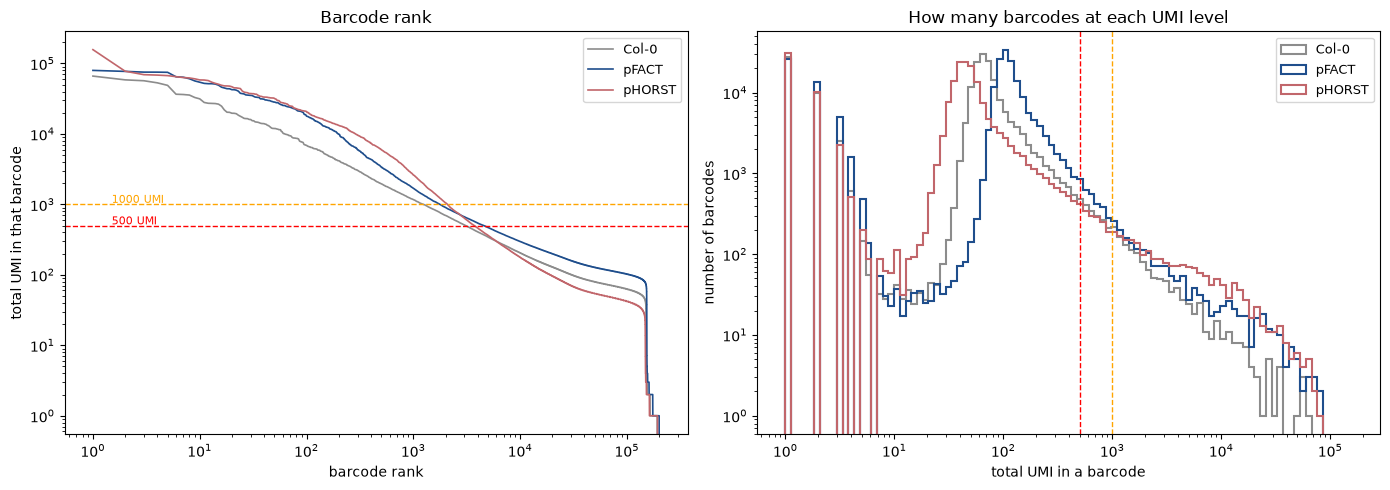

         UMI range       Col-0       pFACT      pHORST
            0 - 10      41,041      46,555      44,636
           10 - 50      11,136         550      86,864
          50 - 100     109,621      47,277      42,701
         100 - 500      27,101     101,132      15,284
       500 - 1,000       1,848       2,794       1,632
     1,000 - 5,000       1,081       1,423       1,485
            5,000+         157         350         598
Col-0   (192,259 barcodes)
       UMI range   barcodes  min genes   median      max  UMI/gene
          0 - 10     41,041          1        1       10      1.00
         10 - 50     11,136          9       45       56      1.04
        50 - 100    109,621         40       63      105      1.06
       100 - 500     27,101         71      131      441      1.10
     500 - 1,000      1,848        293      513      793      1.28
   1,000 - 5,000      1,081        549     1021     2674      1.49
          5,000+        157       1790     3394     9089      2.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

COLOR = {"Col-0": "#8c8c8c", "pFACT": "#1f4e8c", "pHORST": "#c1666b"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------------------------
# LEFT - barcode rank plot
# x = barcodes sorted high->low, y = that barcode's UMI count
# ---------------------------------------------------------------------------
for sample in SAMPLES:
    umi = np.sort(all_adata[sample].obs["total_counts"].values)[::-1]
    rank = np.arange(1, len(umi) + 1)
    ax1.loglog(rank, umi, lw=1.2, color=COLOR[sample], label=sample)

ax1.axhline(500, color="red", ls="--", lw=1)
ax1.axhline(1000, color="orange", ls="--", lw=1)
ax1.text(1.5, 520, "500 UMI", color="red", fontsize=8)
ax1.text(1.5, 1050, "1000 UMI", color="orange", fontsize=8)
ax1.set_xlabel("barcode rank")
ax1.set_ylabel("total UMI in that barcode")
ax1.set_title("Barcode rank")
ax1.legend(fontsize=9)

# ---------------------------------------------------------------------------
# RIGHT - how many barcodes have each UMI count
# x = UMI count (real numbers, log spaced)
# y = NUMBER OF BARCODES (not density)
# ---------------------------------------------------------------------------
# log-spaced bins so the x axis can show real UMI numbers
biggest = 0
for sample in SAMPLES:
    m = all_adata[sample].obs["total_counts"].values.max()
    if m > biggest:
        biggest = m

bins = np.logspace(0, np.log10(biggest), 100)

for sample in SAMPLES:
    umi = all_adata[sample].obs["total_counts"].values
    umi = umi[umi > 0]
    ax2.hist(umi, bins=bins, histtype="step", lw=1.5,
             color=COLOR[sample], label=sample)

ax2.set_xscale("log")
ax2.set_yscale("log")          # counts span 1 to ~50,000, so log makes the tail visible

ax2.axvline(500, color="red", ls="--", lw=1)
ax2.axvline(1000, color="orange", ls="--", lw=1)
ax2.set_xlabel("total UMI in a barcode")
ax2.set_ylabel("number of barcodes")
ax2.set_title("How many barcodes at each UMI level")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# --- the same thing as a table ---------------------------------------------
print(f"{'UMI range':>18}", end="")
for sample in SAMPLES:
    print(f"{sample:>12}", end="")
print()

edges = [0, 10, 50, 100, 500, 1000, 5000, 10**9]
for i in range(len(edges) - 1):
    low, high = edges[i], edges[i + 1]
    label = f"{low:,} - {high:,}" if high < 10**9 else f"{low:,}+"
    print(f"{label:>18}", end="")
    for sample in SAMPLES:
        umi = all_adata[sample].obs["total_counts"].values # .obs is the barcode table (one row per barcode), and total_counts is that barcode's total UMI count.
        n = ((umi > low) & (umi <= high)).sum()
        print(f"{n:>12,}", end="")
    print()


import numpy as np

edges = [0, 10, 50, 100, 500, 1000, 5000, 10**9]

for sample in SAMPLES:
    umi   = all_adata[sample].obs["total_counts"].values
    genes = all_adata[sample].obs["n_genes_by_counts"].values

    print("=" * 74)
    print(f"{sample}   ({len(umi):,} barcodes)")
    print(f"{'UMI range':>16} {'barcodes':>10} {'min genes':>10} "
          f"{'median':>8} {'max':>8} {'UMI/gene':>9}")

    for i in range(len(edges) - 1):
        low, high = edges[i], edges[i + 1]

        in_bin = (umi > low) & (umi <= high)
        if in_bin.sum() == 0:
            continue

        g = genes[in_bin]
        u = umi[in_bin]

        label = f"{low:,} - {high:,}" if high < 10**9 else f"{low:,}+"
        print(f"{label:>16} {in_bin.sum():>10,} {g.min():>10.0f} "
              f"{np.median(g):>8.0f} {g.max():>8.0f} "
              f"{np.median(u) / np.median(g):>9.2f}")



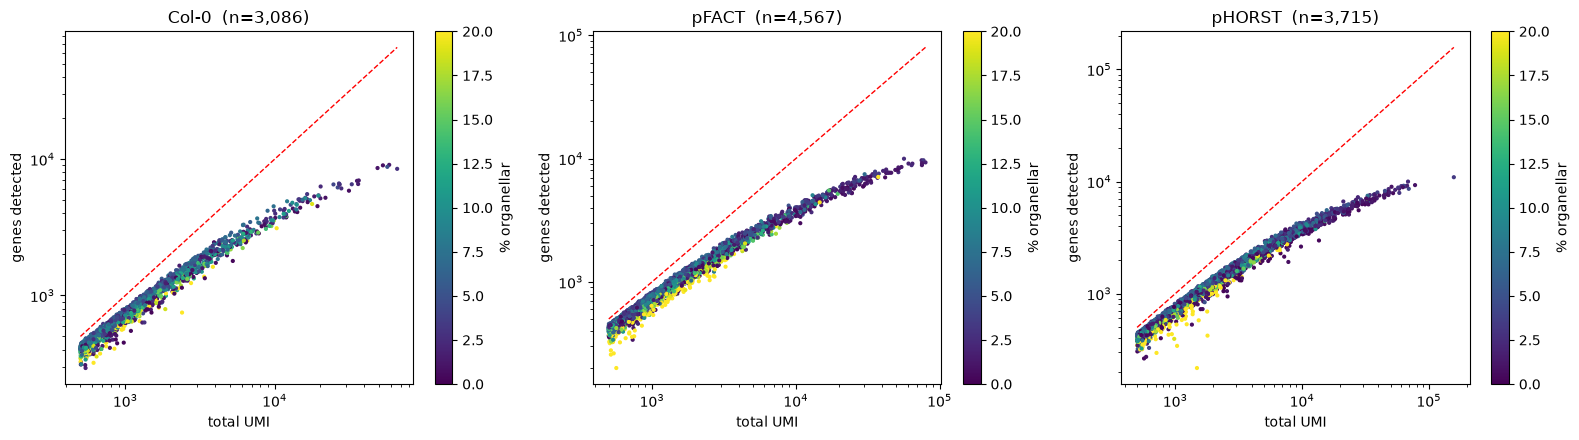

sample        n>500  median %org   90th pct   99th pct     >10%
Col-0         3,086          6.9       12.5       20.6      644
pFACT         4,567          7.1       14.8       24.5    1,263
pHORST        3,715          6.0       13.2       25.5      777


In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, sample in zip(axes, SAMPLES):
    adata = all_adata[sample]
    umi   = adata.obs["total_counts"].values
    genes = adata.obs["n_genes_by_counts"].values
    org   = adata.obs["pct_counts_organellar"].values

    keep = umi > 500                      # candidate cells only
    sc_ = ax.scatter(umi[keep], genes[keep], c=org[keep], s=4,
                     cmap="viridis", vmin=0, vmax=20)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.plot([500, umi.max()], [500, umi.max()], "r--", lw=1)   # 1 UMI per gene
    ax.set_xlabel("total UMI"); ax.set_ylabel("genes detected")
    ax.set_title(f"{sample}  (n={keep.sum():,})")
    plt.colorbar(sc_, ax=ax, label="% organellar")

plt.tight_layout(); plt.show()

# organellar distribution among candidate cells
print(f"{'sample':10s} {'n>500':>8} {'median %org':>12} {'90th pct':>10} {'99th pct':>10} {'>10%':>8}")
for sample in SAMPLES:
    adata = all_adata[sample]
    keep = adata.obs["total_counts"].values > 500
    org = adata.obs["pct_counts_organellar"].values[keep]
    print(f"{sample:10s} {keep.sum():>8,} {np.median(org):>12.1f} "
          f"{np.percentile(org,90):>10.1f} {np.percentile(org,99):>10.1f} "
          f"{(org>10).sum():>8,}")


In [21]:
import numpy as np

print(f"{'sample':10s} {'n>500':>8} {'min genes':>10} {'max':>9} {'median':>8} {'<200?':>8}")
for sample in SAMPLES:
    adata = all_adata[sample]
    keep = adata.obs["total_counts"].values > 500
    genes = adata.obs["n_genes_by_counts"].values[keep]
    print(f"{sample:10s} {keep.sum():>8,} {genes.min():>10.0f} "
          f"{np.max(genes):>8.0f}{np.median(genes):>8.0f} "
          f"{(genes < 200).sum():>8,}")


sample        n>500  min genes       max   median    <200?
Col-0         3,086        293     9089     635        0
pFACT         4,567        200     9967     620        0
pHORST        3,715        217    10921     808        0


In [22]:
# extracting out barcodes with < 500 genes as empty droplets
# setting the threshold values based on the above
# thresholds
# adding no filder for genes since in genes in every cell is 200, the scanpy default
# is to filder cells with genes less than 0
MIN_COUNTS = 500
MAX_ORGANELLAR = 10       # scanpy's default based on google AI search 

filtered = {}

for sample in SAMPLES:
    adata = all_adata[sample]

    umi   = adata.obs["total_counts"].values
    genes = adata.obs["n_genes_by_counts"].values
    org   = adata.obs["pct_counts_organellar"].values

    # --- see what each filter removes, one at a time -----------------------
    pass_umi   = umi > MIN_COUNTS
    pass_org   = org < MAX_ORGANELLAR
    # called cell if it passes the threshold
    is_cell    = pass_umi & pass_org

    print("=" * 62)
    print(f"{sample}   ({adata.n_obs:,} barcodes)")
    print(f"  pass UMI  > {MIN_COUNTS:<6} : {pass_umi.sum():>8,}")
    print(f"  pass org  < {MAX_ORGANELLAR}%     : {pass_org.sum():>8,}")
    print(f"  pass ALL THREE      : {is_cell.sum():>8,}  <- cells")

    # --- write the flag onto the full object -------------------------------
    adata.obs["is_cell"] = is_cell

    # --- and make a filtered copy ------------------------------------------
    # deleting nothing just marking cells as True
    cells = adata[is_cell].copy()

    cells.uns["filtered"] = True
    cells.uns["filter_min_counts"] = MIN_COUNTS
    cells.uns["filter_max_pct_organellar"] = MAX_ORGANELLAR

    print(f"  median UMI  : {cells.obs['total_counts'].median():>8.0f}")
    print(f"  median genes: {cells.obs['n_genes_by_counts'].median():>8.0f}")

    cells.write_h5ad(f"{OUT_DIR}/{sample}_cr-like-em_filtered.h5ad", compression="gzip")
    filtered[sample] = cells

print("\nwrote *_cr-like-em_filtered.h5ad")



Col-0   (192,259 barcodes)
  pass UMI  > 500    :    3,086
  pass org  < 10%     :  181,567
  pass ALL THREE      :    2,442  <- cells
  median UMI  :      843
  median genes:      636
pFACT   (200,283 barcodes)
  pass UMI  > 500    :    4,567
  pass org  < 10%     :  191,183
  pass ALL THREE      :    3,304  <- cells
  median UMI  :      796
  median genes:      619
pHORST   (193,477 barcodes)
  pass UMI  > 500    :    3,715
  pass org  < 10%     :  174,767
  pass ALL THREE      :    2,937  <- cells
  median UMI  :     1261
  median genes:      892

wrote *_cr-like-em_filtered.h5ad


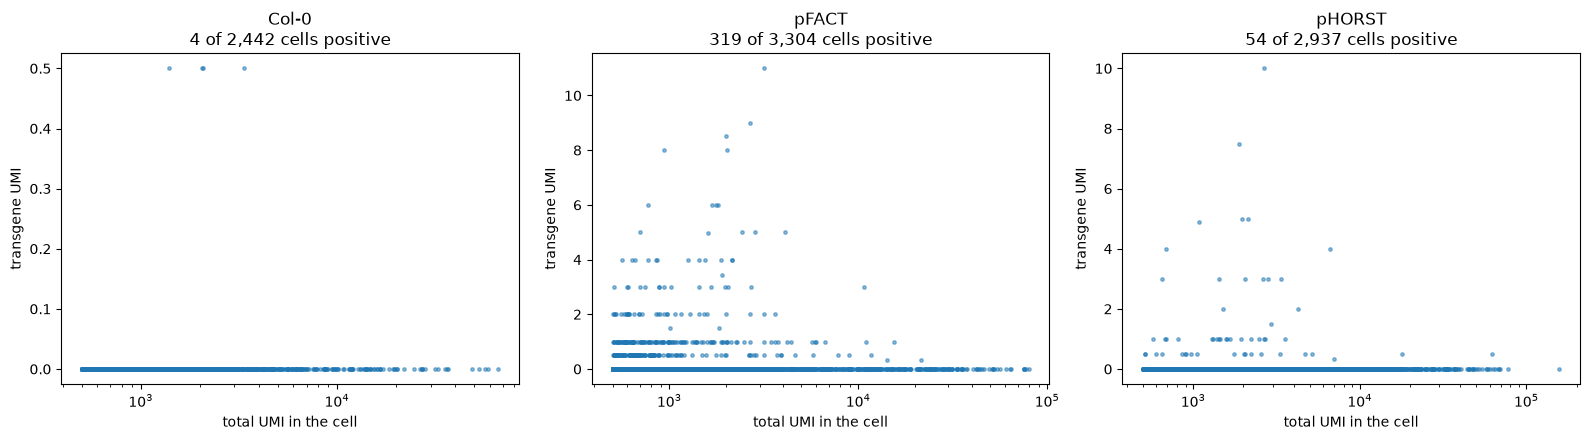

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

TRANSGENE = "AT4G28110.Fusion"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, sample in zip(axes, SAMPLES):
    adata = filtered[sample]

    # total UMIs per cell
    total = adata.obs["total_counts"].values

    # transgene UMIs per cell (.toarray() turns the sparse column into a plain array)
    # extract all cells only TRANSGENE col and to array
    fusion = adata[:, TRANSGENE].X.toarray().ravel()

    n_cells = len(fusion)
    n_pos = (fusion > 0).sum()

    ax.scatter(total, fusion, s=6, alpha=0.5)
    ax.set_xscale("log")
    ax.set_xlabel("total UMI in the cell")
    ax.set_ylabel("transgene UMI")
    ax.set_title(f"{sample}\n{n_pos:,} of {n_cells:,} cells positive")

plt.tight_layout()
plt.show()


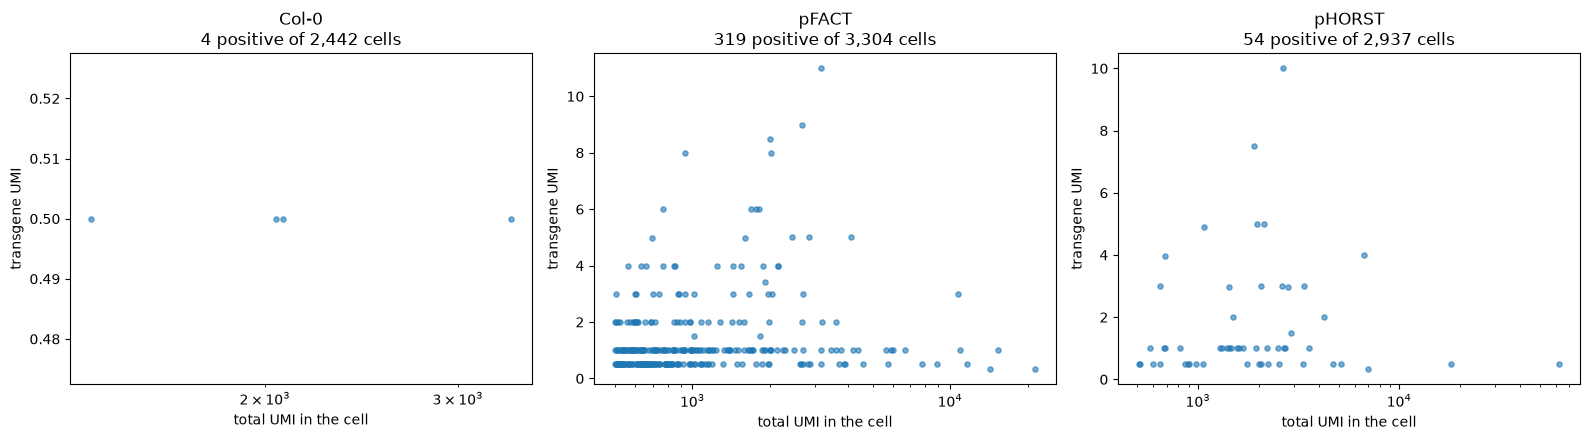


Col-0
         UMI range   cells  positive  % positive
         500-1,000   1,482         0        0.0%
       1,000-2,000     586         1        0.2%
       2,000-5,000     245         3        1.2%
      5,000-20,000     110         0        0.0%
           20,000+      19         0        0.0%

pFACT
         UMI range   cells  positive  % positive
         500-1,000   2,066       202        9.8%
       1,000-2,000     598        67       11.2%
       2,000-5,000     327        37       11.3%
      5,000-20,000     221        12        5.4%
           20,000+      92         1        1.1%

pHORST
         UMI range   cells  positive  % positive
         500-1,000   1,215        14        1.2%
       1,000-2,000     644        16        2.5%
       2,000-5,000     505        19        3.8%
      5,000-20,000     470         4        0.9%
           20,000+     103         1        1.0%


In [25]:
import matplotlib.pyplot as plt
import numpy as np

TRANSGENE = "AT4G28110.Fusion"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, sample in zip(axes, SAMPLES):
    adata = filtered[sample]
    total = adata.obs["total_counts"].values
    fusion = adata[:, TRANSGENE].X.toarray().ravel()

    # keep only the cells that actually have transgene signal
    pos = fusion > 0

    ax.scatter(total[pos], fusion[pos], s=14, alpha=0.6)
    ax.set_xscale("log")
    ax.set_xlabel("total UMI in the cell")
    ax.set_ylabel("transgene UMI")
    ax.set_title(f"{sample}\n{pos.sum():,} positive of {len(fusion):,} cells")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# THE AMBIENT TEST
#
# Ambient RNA is scooped up in proportion to droplet size. So if the transgene
# signal is just soup, the % of positive cells should RISE with total UMI -
# bigger cells catch more of everything.
#
# If the % stays flat, or does not rise, the signal is NOT explained by ambient.
# ---------------------------------------------------------------------------
bins = [(500, 1000), (1000, 2000), (2000, 5000), (5000, 20000), (20000, 10**9)]

for sample in SAMPLES:
    adata = filtered[sample]
    total = adata.obs["total_counts"].values
    fusion = adata[:, TRANSGENE].X.toarray().ravel()

    print(f"\n{sample}")
    print(f"  {'UMI range':>16} {'cells':>7} {'positive':>9} {'% positive':>11}")

    for low, high in bins:
        in_bin = (total > low) & (total <= high)
        if in_bin.sum() == 0:
            continue
        n_pos = (fusion[in_bin] > 0).sum()
        label = f"{low:,}-{high:,}" if high < 10**9 else f"{low:,}+"
        print(f"  {label:>16} {in_bin.sum():>7,} {n_pos:>9,} "
              f"{n_pos/in_bin.sum()*100:>10.1f}%")


In [26]:
TRANSGENE = "AT4G28110.Fusion"

print(f"{'sample':10s} {'cells':>7} {'>0':>7} {'>=1':>7} {'>=2':>7} {'>=3':>7}")
for sample in SAMPLES:
    adata = filtered[sample]
    fusion = adata[:, TRANSGENE].X.toarray().ravel()
    print(f"{sample:10s} {len(fusion):>7,} "
          f"{(fusion > 0).sum():>7,} {(fusion >= 1).sum():>7,} "
          f"{(fusion >= 2).sum():>7,} {(fusion >= 3).sum():>7,}")


sample       cells      >0     >=1     >=2     >=3
Col-0        2,442       4       0       0       0
pFACT        3,304     319     198      74      39
pHORST       2,937      54      34      15      10


In [27]:
TRANSGENE = "AT4G28110.Fusion"

print(f"{'sample':10s} {'--- all barcodes ---':>26} {'--- filtered cells ---':>26}")
print(f"{'':10s} {'n':>10} {'>0':>7} {'>=1':>7} {'n':>10} {'>0':>7} {'>=1':>7}")

for sample in SAMPLES:
    raw = all_adata[sample][:, TRANSGENE].X.toarray().ravel()
    cel = filtered[sample][:, TRANSGENE].X.toarray().ravel()
    print(f"{sample:10s} {len(raw):>10,} {(raw>0).sum():>7,} {(raw>=1).sum():>7,} "
          f"{len(cel):>10,} {(cel>0).sum():>7,} {(cel>=1).sum():>7,}")


sample           --- all barcodes ---     --- filtered cells ---
                    n      >0     >=1          n      >0     >=1
Col-0         192,259      14       1      2,442       4       0
pFACT         200,283   2,519   1,230      3,304     319     198
pHORST        193,477     209     107      2,937      54      34


In [ ]:
import scanpy as sc
import numpy as np

sc.settings.verbosity = 1

HVGS = 2000

clustered = {}

for sample in SAMPLES:
    print("=" * 60)
    print(sample)

    adata = filtered[sample].copy()

    # keep the raw counts before anything overwrites them
    adata.layers["counts"] = adata.X.copy()

    # EM gives fractional counts; some steps want whole numbers
    adata.X.data = np.round(adata.X.data)

    # --- normalise: put every cell on the same total, then log --------------
    # --- depth normalization - cells span between 500 and 150,000 UMIs.
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # keep a copy of the full normalised matrix before subsetting to HVGs
    adata.raw = adata

    # --- pick the genes that vary between cells----------------------------
    sc.pp.highly_variable_genes(adata, n_top_genes=HVGS)
    print("  variable genes:", adata.var["highly_variable"].sum())
    adata = adata[:, adata.var["highly_variable"]].copy()

    # --- reduce to principal components ------------------------------------
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=50, svd_solver="arpack")

    # --- build the cell-cell graph and cluster it ---------------------------
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
    sc.tl.leiden(adata, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2)
    sc.tl.umap(adata)

    n_clusters = adata.obs["leiden"].nunique()
    print(f"  {adata.n_obs:,} cells -> {n_clusters} clusters")
    print(adata.obs["leiden"].value_counts().sort_index().to_string())

    clustered[sample] = adata
    adata.write_h5ad(f"{OUT_DIR}/{sample}_clustered_{HVGS}.h5ad", compression="gzip")



Col-0
  variable genes: 10000


/data1/bfernando/conda_envs/alevinfry/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/data1/bfernando/conda_envs/alevinfry/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  2,442 cells -> 15 clusters
leiden
0     139
1      14
2      55
3      74
4     109
5     386
6     415
7     134
8      91
9     128
10     38
11    159
12    376
13    115
14    209
pFACT
  variable genes: 10000


/data1/bfernando/conda_envs/alevinfry/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  3,304 cells -> 16 clusters
leiden
0     326
1     229
2     112
3     180
4     117
5     588
6     150
7     146
8     241
9     506
10    187
11     15
12     50
13    194
14    245
15     18
pHORST
  variable genes: 10000


/data1/bfernando/conda_envs/alevinfry/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  2,937 cells -> 18 clusters
leiden
0     182
1     179
2     146
3     125
4     218
5      98
6     395
7      74
8      75
9     151
10     30
11    168
12     73
13    255
14    544
15     27
16     98
17     99


In [29]:
TRANSGENE = "AT4G28110.Fusion"

for sample in SAMPLES:
    adata = clustered[sample]

    # transgene comes from .raw, since the object was subset to variable genes
    fusion = adata.raw[:, TRANSGENE].X.toarray().ravel()
    adata.obs["transgene"] = fusion

    tab = adata.obs.groupby("leiden", observed=True).agg(
        cells=("transgene", "size"),
        positive=("transgene", lambda v: (v >= 1).sum()),
    )
    tab["pct_positive"] = (tab["positive"] / tab["cells"] * 100).round(1)

    print(f"\n{'='*50}\n{sample}   ({int(tab['positive'].sum())} positive cells total)")
    print(tab.sort_values("pct_positive", ascending=False).to_string())



Col-0   (0 positive cells total)
        cells  positive  pct_positive
leiden                               
0         139         0           0.0
1          14         0           0.0
2          55         0           0.0
3          74         0           0.0
4         109         0           0.0
5         386         0           0.0
6         415         0           0.0
7         134         0           0.0
8          91         0           0.0
9         128         0           0.0
10         38         0           0.0
11        159         0           0.0
12        376         0           0.0
13        115         0           0.0
14        209         0           0.0

pFACT   (193 positive cells total)
        cells  positive  pct_positive
leiden                               
8         241        98          40.7
11         15         2          13.3
9         506        42           8.3
2         112         5           4.5
4         117         5           4.3
13        194     

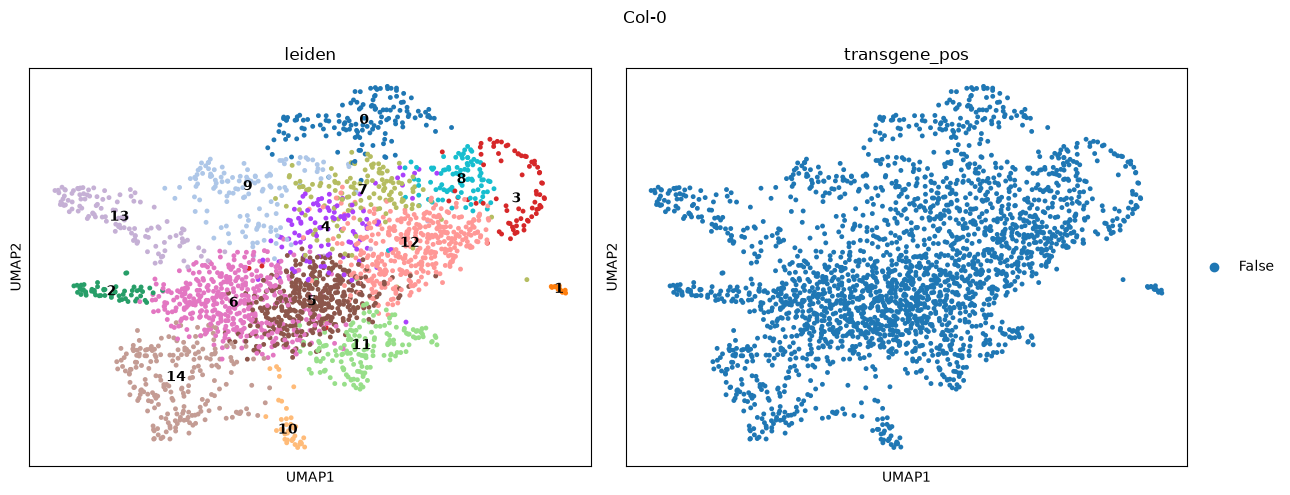

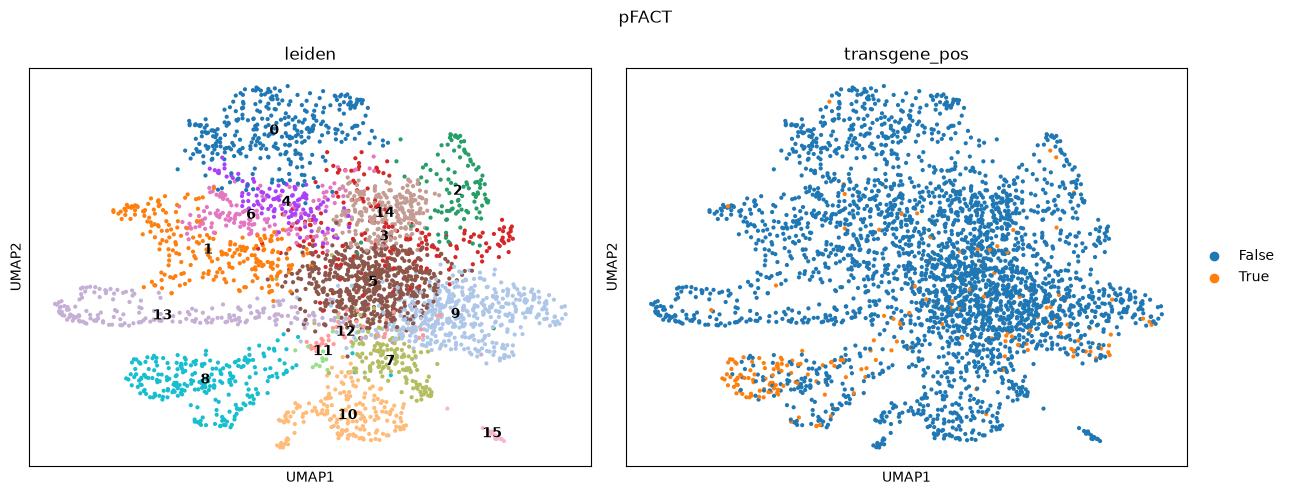

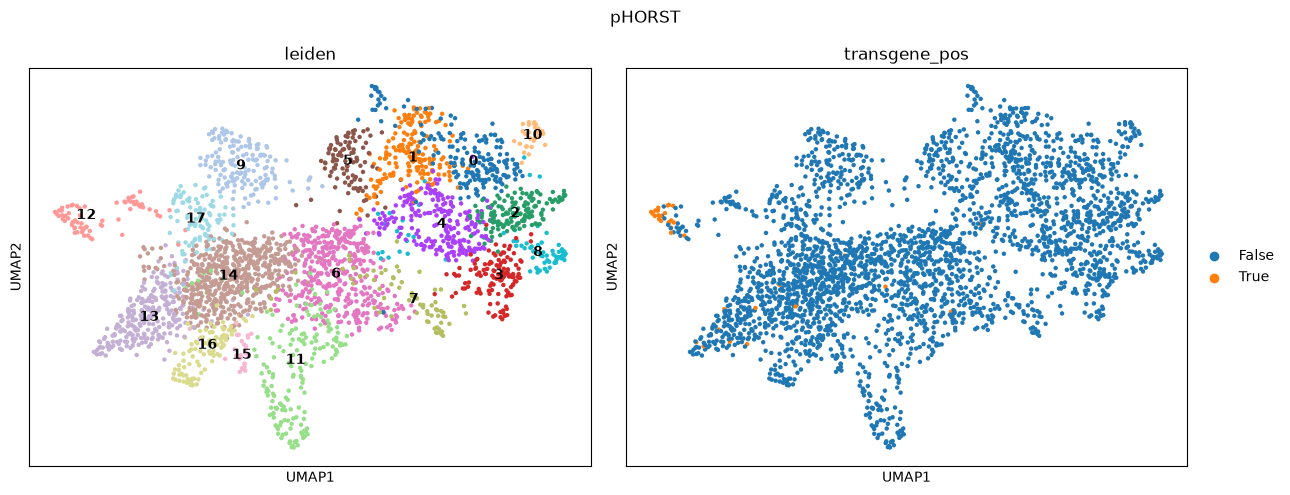

In [30]:
import matplotlib.pyplot as plt

for sample in SAMPLES:
    adata = clustered[sample]
    adata.obs["transgene_pos"] = (adata.obs["transgene"] >= 1).astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, legend_loc="on data")
    sc.pl.umap(adata, color="transgene_pos", ax=axes[1], show=False)
    fig.suptitle(sample)
    plt.tight_layout(); plt.show()


In [31]:
TRANSGENE = "AT4G28110.Fusion"

for sample in ["pFACT", "pHORST"]:
    adata = clustered[sample]
    fusion = adata.raw[:, TRANSGENE].X.toarray().ravel()
    adata.obs["transgene"] = fusion

    tab = adata.obs.groupby("leiden", observed=True).agg(
        cells=("transgene", "size"),
        positive=("transgene", lambda v: (v >= 1).sum()),
    )
    tab["pct_positive"] = (tab["positive"] / tab["cells"] * 100).round(1)
    overall = tab["positive"].sum() / tab["cells"].sum() * 100

    print(f"\n{sample}  —  {int(tab['positive'].sum())} positive / {int(tab['cells'].sum())} cells "
          f"({overall:.1f}% overall)")
    print(tab.sort_values("pct_positive", ascending=False).to_string())



pFACT  —  193 positive / 3304 cells (5.8% overall)
        cells  positive  pct_positive
leiden                               
8         241        98          40.7
11         15         2          13.3
9         506        42           8.3
2         112         5           4.5
4         117         5           4.3
13        194         7           3.6
5         588        21           3.6
12         50         1           2.0
3         180         3           1.7
7         146         2           1.4
1         229         3           1.3
10        187         2           1.1
6         150         1           0.7
0         326         1           0.3
14        245         0           0.0
15         18         0           0.0

pHORST  —  34 positive / 2937 cells (1.2% overall)
        cells  positive  pct_positive
leiden                               
12         73        21          28.8
13        255         7           2.7
8          75         1           1.3
17         99         

In [32]:
for sample, target in [("pFACT", "8"), ("pHORST", "12")]:
    adata = clustered[sample]
    sc.tl.rank_genes_groups(adata, "leiden", groups=[target], reference="rest", method="wilcoxon")
    top = sc.get.rank_genes_groups_df(adata, group=target).head(25)
    print(f"\n{'='*50}\n{sample} cluster {target} — top markers")
    print(top[["names", "logfoldchanges", "pvals_adj"]].to_string(index=False))



pFACT cluster 8 — top markers
                  names  logfoldchanges    pvals_adj
AT5G09530.Araport11.447        4.730772 1.315468e-92
AT3G44550.Araport11.447        6.135583 7.639683e-74
AT2G18370.Araport11.447        5.332328 6.749074e-67
AT5G09480.Araport11.447        4.980932 9.100261e-65
AT1G55330.Araport11.447        5.164297 5.149798e-60
AT3G32980.Araport11.447        4.343010 5.149798e-60
AT1G72510.Araport11.447        3.910753 1.408270e-59
AT1G68850.Araport11.447        5.560664 4.967347e-59
AT5G41040.Araport11.447        5.172627 1.230058e-57
AT1G08510.Araport11.447        4.578488 2.489454e-56
AT4G24130.Araport11.447        5.641276 1.158971e-54
AT2G22470.Araport11.447        3.837719 2.202186e-51
AT3G13520.Araport11.447        4.411752 8.411539e-51
AT2G38380.Araport11.447        4.793616 8.942798e-49
AT4G38080.Araport11.447        4.195370 2.145550e-46
AT5G11740.Araport11.447        3.344939 7.756082e-46
AT4G09030.Araport11.447        3.551960 1.460118e-43
AT1G55020.Arapo